In [1]:
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns

sns.set_context('paper',font_scale=1.5)
sns.set_style('ticks')

# Quick-start

The central class of the library is `DefectsAnalysis`. The most flexible way to initialize it is by using a `pandas.DataFrame`
The minimal approach is to initialize the class with a `pandas.DataFrame`. Columns are:
- `name` : Name of the defect, naming conventions described below.
- `charge` : Defect charge.
- `multiplicity` : Multiplicity in the unit cell.
- `energy_diff` : Energy of the defective cell minus the energy of the pristine cell in eV.
- `bulk_volume` : Pristine cell volume in $\mathrm{\AA^3}$

Defect naming: (element = $A$)
- `Vacancy`: `"Vac_A"` (symbol=$V_{A}$)
- `Interstitial`: `"Int_A"` (symbol=$A_{i}$)
- `Substitution`: `"Sub_B_on_A"` (symbol=$B_{A}$)
- `Polaron`: `"Pol_A"` (symbol=${A}_{A}$)
- `DefectComplex`: `"Vac_O;Int_A"` (symbol=$V_A - A_i$)

Let's create an example `DataFrame` with <span style="color:red"> made-up energies </span> as an example. We are studying $SrO$ and have energies for the neutral and charged $Sr$ and $O$ vacancies.

In [3]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
df

,name,charge,multiplicity,energy_diff,bulk_volume
0,Vac_O,2,1,7.0,800
1,Vac_O,0,1,10.8,800
2,Vac_Sr,-2,1,8.0,800
3,Vac_Sr,0,1,7.8,800


In [ ]:
# Initialize DefectsAnalysis object
da = DefectsAnalysis.from_dataframe(df,band_gap=2,vbm=0) # band gap and valence band maximum in eV

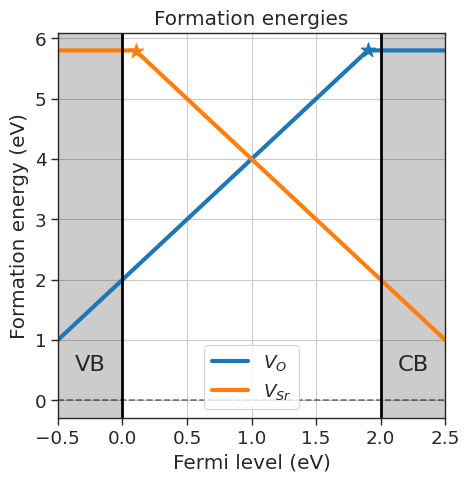

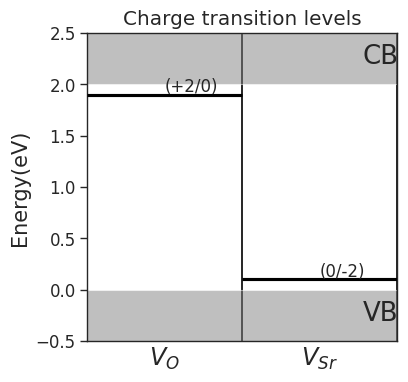

In [ ]:
import matplotlib.pyplot as plt


chempots = {'O':-5,'Sr':-2} # Define chemical potentials for each element in a dictionary

# Plot formation energies
da.plot_formation_energies(chemical_potentials=chempots,title='Formation energies',figsize=(5,5)).show()

# Plot charge transition levels
da.plot_ctl(figsize=(4,4),fontsize=12)
plt.title('Charge transition levels');

##### Fermi level dictated by charge neutrality

`defermi` also offers an easy way to study the defect equilibrium dictated by charge neutrality in different conditions. Defect concentrations can be plotted as a function of the oxygen partial pressure (Brouwer diagram) and dopant concentration with one line of code.

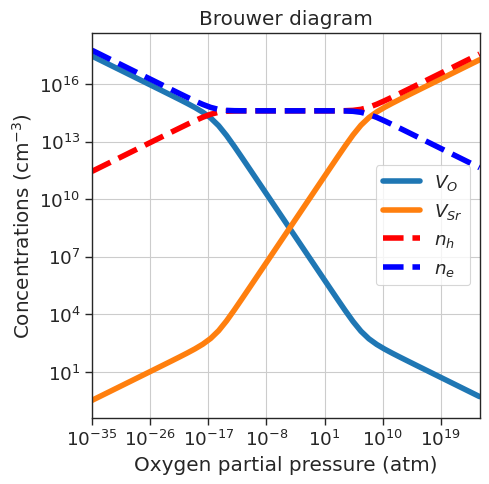

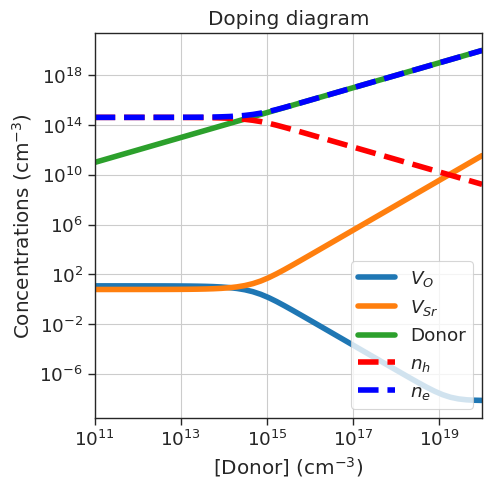

In [35]:
# Brouwer diagram

precursors = {'SrO':-10} # Reservoir and energy per formula unit for the chemical potentials definition
oxygen_ref = -4.95  # chemical potential of oxygen at 0 K and standard pressure
bulk_dos = {'m_eff_e':0.5, 'm_eff_h':0.4}  # effective masses for the charge carriers calculation

da.plot_brouwer_diagram(
                    bulk_dos=bulk_dos,
                    temperature=1000, # Kelvin
                    precursors=precursors,
                    oxygen_ref=oxygen_ref,
                    pressure_range=(1e-35,1e25), # atm
                    figsize=(5,5))
plt.title('Brouwer diagram')
plt.show()

# Doping diagram
da.plot_doping_diagram(
                variable_defect_specie={'name':'Donor','charge':1},
                concentration_range=(1e11,1e20),  # cm^-3
                chemical_potentials=chempots,
                bulk_dos=bulk_dos,
                temperature=1000,  # Kelvin
                figsize=(5,5))
plt.title('Doping diagram');